# Exploratory Data Analysis (EDA) Project

## Objective
To analyze Netflix dataset and uncover patterns, trends, and insights using statistical summaries and visualizations.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# Load Dataset
Loading Netflix dataset using Pandas.

In [2]:
# Load dataset

df = pd.read_csv("netflix_titles.csv")

# Display first 5 rows

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Dataset Information
Checking rows, columns, and data types.

In [3]:
# Dataset shape

print("Dataset Shape:", df.shape)

Dataset Shape: (8807, 12)


In [4]:
# Dataset info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


# Missing Values
Checking null values in dataset.

In [5]:
# Missing values

df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

# Data Cleaning
Handling missing values and duplicates.

In [6]:
# Remove duplicates

df.drop_duplicates(inplace=True)

print("Duplicates removed")

Duplicates removed


In [7]:
# Fill missing country values

df['country'] = df['country'].fillna('Unknown')

In [8]:
# Fill missing rating values

df['rating'] = df['rating'].fillna('Not Rated')

In [9]:
# Check missing values again

df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country            0
date_added        10
release_year       0
rating             0
duration           3
listed_in          0
description        0
dtype: int64

# Statistical Summary
Understanding numerical data distribution.

In [10]:
# Statistical summary

df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


# Movies vs TV Shows
Analyzing content distribution.

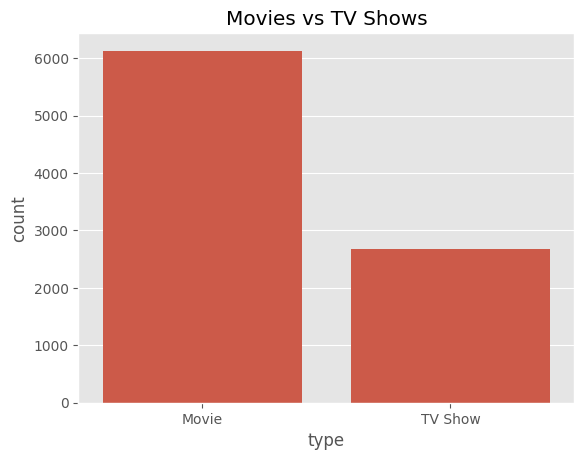

In [11]:
# Count plot for content type

sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows")

plt.show()

# Top Countries
Analyzing content production by country.

In [12]:
# Top countries

top_countries = df['country'].value_counts().head(10)

top_countries

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

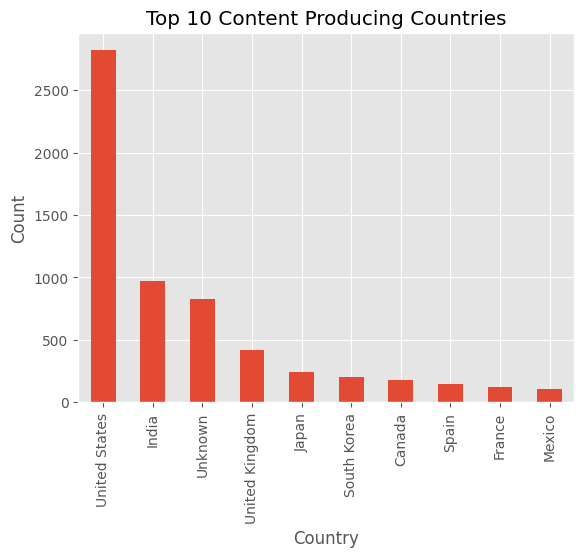

In [13]:
# Visualize top countries

top_countries.plot(kind='bar')

plt.title("Top 10 Content Producing Countries")

plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

# Ratings Analysis
Analyzing content ratings.

In [14]:
# Ratings distribution

df['rating'].value_counts().head(10)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

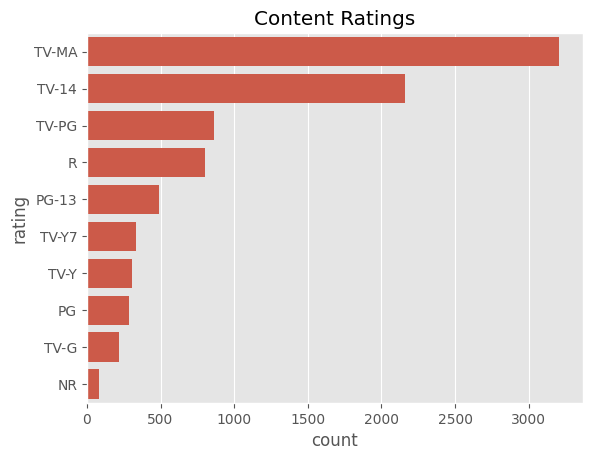

In [15]:
# Ratings visualization

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index[:10]
)

plt.title("Content Ratings")

plt.show()

# Release Year Trends
Analyzing content released over years.

In [16]:
# Content released each year

df['release_year'].value_counts().head()

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
Name: count, dtype: int64

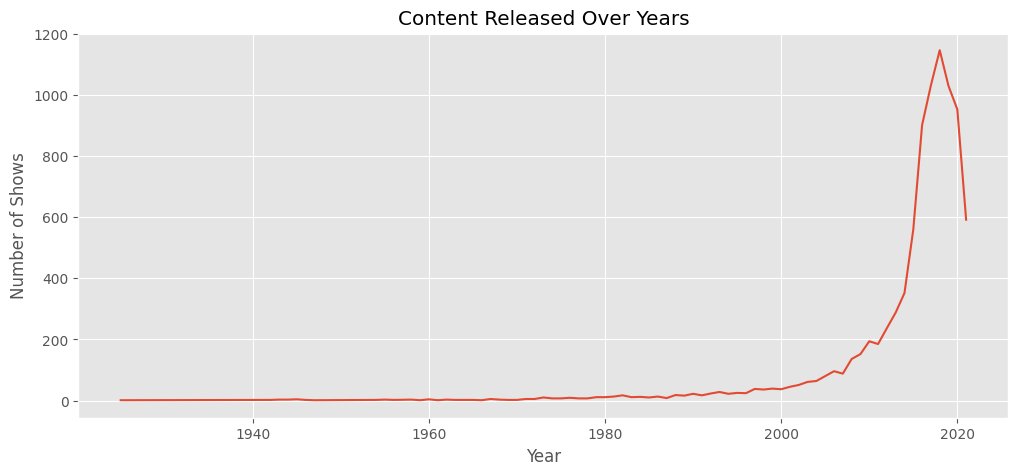

In [17]:
# Release year trend graph

df['release_year'].value_counts()\
    .sort_index()\
    .plot(figsize=(12,5))

plt.title("Content Released Over Years")

plt.xlabel("Year")
plt.ylabel("Number of Shows")

plt.show()

# Correlation Analysis
Checking relationships between numerical features.

In [18]:
# Select numerical columns

numeric_df = df.select_dtypes(include=np.number)

numeric_df.head()

,release_year
0,2020
1,2021
2,2021
3,2021
4,2021


In [19]:
# Correlation matrix

correlation = numeric_df.corr()

correlation

,release_year
release_year,1.0


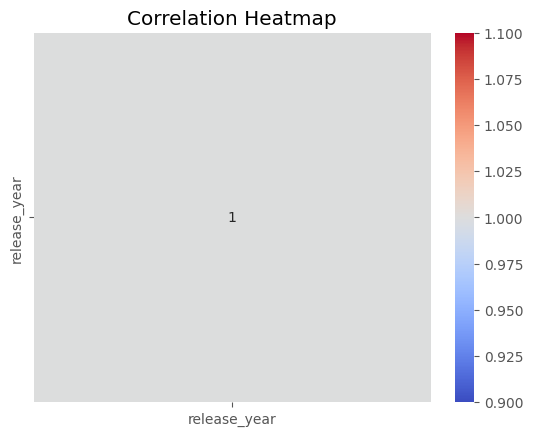

In [20]:
# Heatmap

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Key Insights

1. Netflix contains more Movies than TV Shows.
2. The United States produces the highest amount of content.
3. Content production increased significantly after 2015.
4. TV-MA is one of the most common content ratings.
5. Data visualizations helped identify important viewing trends.

# Conclusion

This project demonstrates Exploratory Data Analysis using the Netflix dataset. 
Various statistical summaries and visualizations were used to uncover patterns and trends in Netflix content. 
The project improved understanding of data exploration, analytical thinking, and storytelling with data.